In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [19]:
# Load dataset

df = pd.read_csv('AB_NYC_2019.csv')

# Display first 5 rows

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [20]:
# Shape of dataset

print("Dataset Shape:", df.shape)

# Dataset information

df.info()

# Column names

print(df.columns)

# Missing values

print(df.isnull().sum())

Dataset Shape: (48895, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_

In [21]:
# Check duplicate rows

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [22]:
# Remove duplicates

df.drop_duplicates(inplace=True)

print("Duplicates Removed")

Duplicates Removed


In [23]:
# Missing values before cleaning

print(df.isnull().sum())

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [24]:
# Fill missing values

df['name'].fillna('Unknown', inplace=True)

df['host_name'].fillna('Unknown', inplace=True)

df['reviews_per_month'].fillna(df['reviews_per_month'].median(), inplace=True)

print("Missing Values Handled")

Missing Values Handled


/tmp/ipykernel_1759/289214865.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['name'].fillna('Unknown', inplace=True)
/tmp/ipykernel_1759/289214865.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

In [25]:
# Check missing values again

print(df.isnull().sum())

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [26]:
# Convert neighborhood names to lowercase

df['neighbourhood_group'] = df['neighbourhood_group'].str.lower()

df['room_type'] = df['room_type'].str.lower()

print("Text Standardization Completed")

Text Standardization Completed


In [27]:
# Statistical summary

print(df.describe())

                 id       host_id      latitude     longitude         price  \
count  4.889500e+04  4.889500e+04  48895.000000  48895.000000  48895.000000   
mean   1.901714e+07  6.762001e+07     40.728949    -73.952170    152.720687   
std    1.098311e+07  7.861097e+07      0.054530      0.046157    240.154170   
min    2.539000e+03  2.438000e+03     40.499790    -74.244420      0.000000   
25%    9.471945e+06  7.822033e+06     40.690100    -73.983070     69.000000   
50%    1.967728e+07  3.079382e+07     40.723070    -73.955680    106.000000   
75%    2.915218e+07  1.074344e+08     40.763115    -73.936275    175.000000   
max    3.648724e+07  2.743213e+08     40.913060    -73.712990  10000.000000   

       minimum_nights  number_of_reviews  reviews_per_month  \
count    48895.000000       48895.000000       48895.000000   
mean         7.029962          23.274466           1.238930   
std         20.510550          44.550582           1.520861   
min          1.000000           0.00

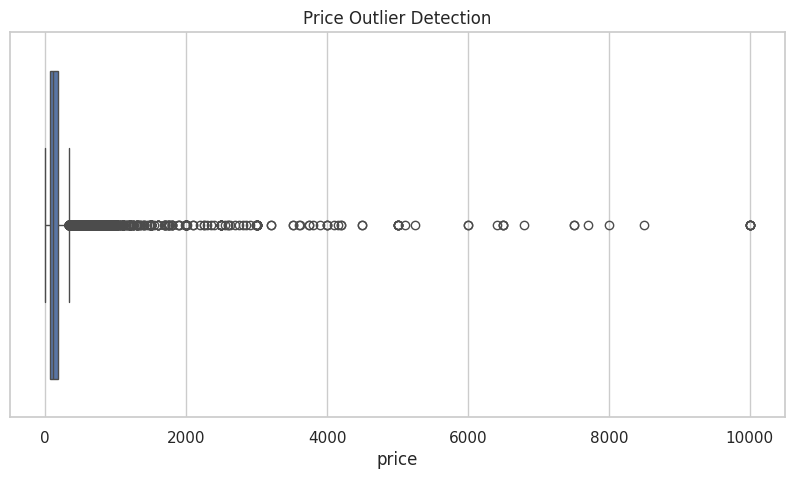

In [28]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['price'])

plt.title('Price Outlier Detection')

plt.show()

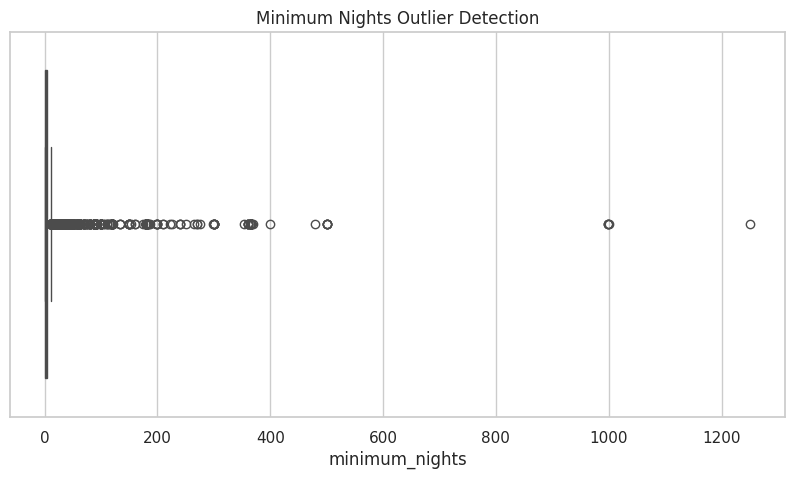

In [29]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['minimum_nights'])

plt.title('Minimum Nights Outlier Detection')

plt.show()

In [30]:
# Remove extreme price outliers

df = df[df['price'] < 1000]

# Remove extreme minimum nights outliers

df = df[df['minimum_nights'] < 100]

print("Outliers Removed")

Outliers Removed


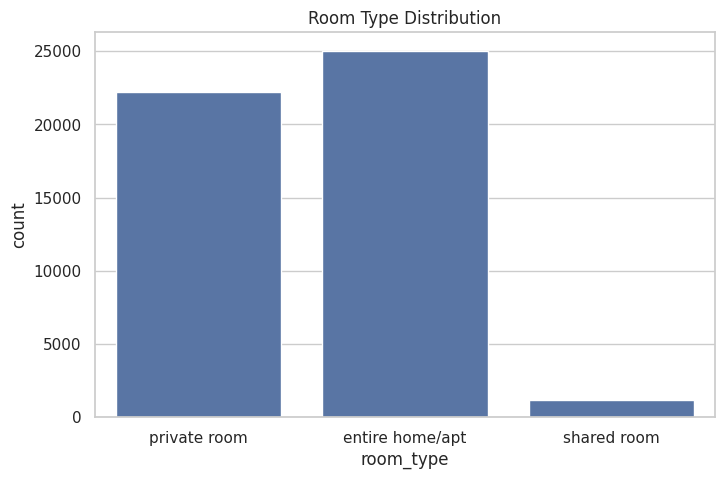

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(x=df['room_type'])

plt.title('Room Type Distribution')

plt.show()

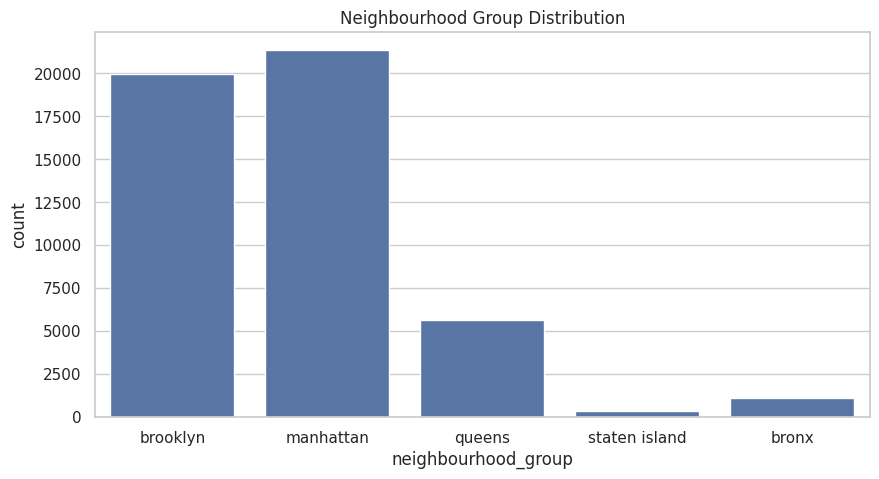

In [32]:
plt.figure(figsize=(10,5))

sns.countplot(x=df['neighbourhood_group'])

plt.title('Neighbourhood Group Distribution')

plt.show()

In [33]:
# Final dataset information

print(df.info())

# Final shape

print("Final Dataset Shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 48419 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48419 non-null  int64  
 1   name                            48419 non-null  object 
 2   host_id                         48419 non-null  int64  
 3   host_name                       48419 non-null  object 
 4   neighbourhood_group             48419 non-null  object 
 5   neighbourhood                   48419 non-null  object 
 6   latitude                        48419 non-null  float64
 7   longitude                       48419 non-null  float64
 8   room_type                       48419 non-null  object 
 9   price                           48419 non-null  int64  
 10  minimum_nights                  48419 non-null  int64  
 11  number_of_reviews               48419 non-null  int64  
 12  last_review                     38611

In [34]:
# Save cleaned dataset

df.to_csv('cleaned_AB_NYC_2019.csv',
          index=False)

print("Cleaned Dataset Saved Successfully")

Cleaned Dataset Saved Successfully


## Business Insights

### 1. Missing Data
Several columns contained missing values, especially reviews_per_month, which were handled using median imputation.

### 2. Duplicate Records
Duplicate rows were identified and removed to maintain data integrity.

### 3. Outliers
Extreme values in price and minimum_nights were detected and removed to improve data quality.

### 4. Standardization
Text formatting inconsistencies were standardized using lowercase conversion.

### 5. Dataset Quality
The cleaned dataset became more accurate, reliable, and suitable for further analysis and machine learning applications.

## Recommendations

### 1. Regular Data Validation
Implement validation checks during data collection to reduce missing and inconsistent values.

### 2. Duplicate Prevention
Use unique identifiers to avoid duplicate records in the future.

### 3. Outlier Monitoring
Monitor unusually high prices and minimum nights values regularly.

### 4. Standardized Input Formats
Maintain consistent formatting standards for text-based data fields.

### 5. Continuous Data Cleaning
Perform periodic data cleaning to maintain high-quality datasets for analysis and business decisions.

## Conclusion

The Data Cleaning project successfully improved the quality and reliability of the Airbnb NYC dataset by handling missing values, removing duplicate records, standardizing text data, and detecting outliers.

The project demonstrated practical skills in data preprocessing and cleaning using Python libraries such as Pandas, Matplotlib, and Seaborn. The cleaned dataset is now more suitable for accurate analysis, visualization, and machine learning applications.